<a href="https://colab.research.google.com/github/digitalchessman-tech/data-science-ipython-notebooks/blob/master/Ejemplo_Arbol_Decision_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
# importación de librerías
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math

In [39]:
# Dataset
dataset = pd.read_csv("/content/sample_data/Social_Network_Ads.csv")
dataset

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [40]:
X = dataset.iloc[:, [2,3]].values
y = dataset.iloc[:, 4].values

In [41]:
# Division en training and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.30, random_state=0)


In [42]:
# Feature Scaling, no haría falta ya que no se basa en distancias Euclideas
# pero se puede utilizar para agilizar los calculos
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [43]:
# Entrenamiento del modelo
from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier(criterion = 'entropy', max_leaf_nodes = None, min_samples_split= 2, max_features = None, random_state = 0)
classifier.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=0)

In [44]:
# Prediction
y_pred = classifier.predict(X_test)

In [45]:
# Matriz de confusión
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[70,  9],
       [ 4, 37]])

In [46]:
# Visualización

def visualize_classifier(model, X, y, ax=None, cmap="rainbow"):
  ax = ax or plt.gca()
  ax.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap=cmap,
            clim=(y.min(), y.max()), zorder=3)
  ax.axis("tight")
  ax.axis("off")
  xlim = ax.get_xlim()
  ylim = ax.get_ylim()

  model.fit(X, y)
  xx, yy = np.meshgrid(np.linspace(*xlim, num=200),
                      np.linspace(*ylim, num=200))
  Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
 # Colores
  n_classes = len(np.unique(y))
  contours = ax.contourf(xx, yy, Z, alpha=0.3, levels =np.arange(n_classes + 1) - 0.5,
                        cmap=cmap, clim=(y.min(), y.max()),
                        zorder=1)
  ax.set(xlim=xlim, ylim=ylim)
  plt.title("Decision Tree Classifier")
  plt.show()



/tmp/ipykernel_2652/3288914603.py:18: UserWarning: The following kwargs were not used by contour: 'clim'
  contours = ax.contourf(xx, yy, Z, alpha=0.3, levels =np.arange(n_classes + 1) - 0.5,


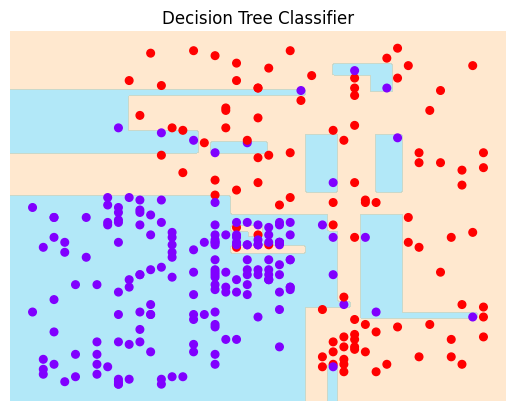

/tmp/ipykernel_2652/3288914603.py:18: UserWarning: The following kwargs were not used by contour: 'clim'
  contours = ax.contourf(xx, yy, Z, alpha=0.3, levels =np.arange(n_classes + 1) - 0.5,


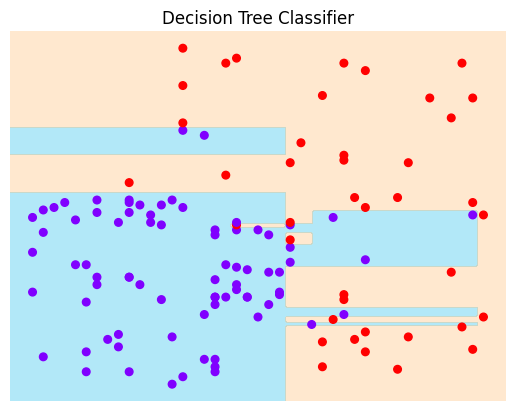

In [48]:
visualize_classifier(classifier, X_train, y_train)
# Test
visualize_classifier(classifier, X_test, y_test)

